# Phase 1: Tuned XGBoost Risk Model

This notebook trains the Phase 1 LendingClub credit risk model using XGBoost. Logistic Regression is kept only as a simple baseline; the production model remains XGBoost.

In [97]:
import pandas as pd
import numpy as np
import xgboost as xgb
import json
import gc
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

from sklearn.model_selection import GridSearchCV
from sklearn.metrics import roc_auc_score
from xgboost import XGBClassifier


In [98]:
# Load Metadata
metadata_path = '../data/processed/features/lendingclub_baseline_metadata.json'
with open(metadata_path, 'r') as f:
    metadata = json.load(f)

# Explicitly drop leaked columns that slipped through previous notebooks
leakage_to_drop = [
    'total_rec_prncp', 
    'total_rec_int', 
    'total_rec_late_fee', 
    'last_fico_range_high', 
    'last_fico_range_low'
]
features = [col for col in metadata['feature_columns'] if col not in leakage_to_drop]

print(f"Loaded {len(features)} features after removing {len(leakage_to_drop)} leaked columns.")

Loaded 123 features after removing 5 leaked columns.


In [99]:
# Memory-Efficient Data Loading
data_path = '../data/processed/features/lendingclub_baseline_features.parquet'

# Load ONLY the required feature columns + target to save RAM
cols_to_load = features + ['target']
df = pd.read_parquet(data_path, columns=cols_to_load)



# Split into X and y
X = df[features]
y = df['target']


In [100]:
# Drop redundant columns and create compact FICO feature
X = X.drop(
    columns=['funded_amnt', 'funded_amnt_inv'],
    errors='ignore'
)

if {'fico_range_low', 'fico_range_high'}.issubset(X.columns):
    X['fico_avg'] = (X['fico_range_low'] + X['fico_range_high']) / 2
    X = X.drop(columns=['fico_range_low', 'fico_range_high'], errors='ignore')

X = X.drop(columns=['num_sats'], errors='ignore')

In [101]:
# Free up memory immediately
del df
gc.collect()

3570

In [102]:
# Train-Validation-Test Split (70/15/15)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp
)

# Work on explicit copies before adding engineered features.
X_train = X_train.copy()
X_val = X_val.copy()
X_test = X_test.copy()

ratio_features = {
    'loan_to_income': ('loan_amnt', 'annual_inc'),
    'installment_to_income': ('installment', 'annual_inc'),
    'credit_utilization_ratio': ('revol_bal', 'total_rev_hi_lim'),
    'recent_credit_ratio': ('num_tl_op_past_12m', 'total_acc'),
}

for new_col, (numerator, denominator) in ratio_features.items():
    for split_df in [X_train, X_val, X_test]:
        split_df[new_col] = split_df[numerator] / split_df[denominator].replace(0, np.nan)

    median_val = X_train[new_col].median()
    X_train[new_col] = X_train[new_col].fillna(median_val)
    X_val[new_col] = X_val[new_col].fillna(median_val)
    X_test[new_col] = X_test[new_col].fillna(median_val)

print(f"Training shape: {X_train.shape}")
print(f"Validation shape: {X_val.shape}")
print(f"Testing shape: {X_test.shape}")

del X_temp, y_temp
gc.collect()

Training shape: (273814, 123)
Validation shape: (58675, 123)
Testing shape: (58675, 123)


0

In [103]:
# Calculate scale_pos_weight to handle the ~80/20 class imbalance
neg_class_count = (y_train == 0).sum()
pos_class_count = (y_train == 1).sum()
scale_pos_weight_val = neg_class_count / pos_class_count

print(f"scale_pos_weight: {scale_pos_weight_val:.2f}")

scale_pos_weight: 3.96


In [104]:
# Initialize and Train Logistic Regression Baseline
print("Training Logistic Regression Baseline...")
# Logistic Regression requires scaled features
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'))
])

lr_pipeline.fit(X_train, y_train)
print("Logistic Regression training complete.")

Training Logistic Regression Baseline...
Logistic Regression training complete.


In [106]:
# Evaluate Logistic Regression
y_train_pred_proba_lr = lr_pipeline.predict_proba(X_train)[:, 1]
y_val_pred_proba_lr = lr_pipeline.predict_proba(X_val)[:, 1]
y_test_pred_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]
y_test_pred_lr = lr_pipeline.predict(X_test)

roc_auc_lr_train = roc_auc_score(y_train, y_train_pred_proba_lr)
roc_auc_lr_val = roc_auc_score(y_val, y_val_pred_proba_lr)
roc_auc_lr_test = roc_auc_score(y_test, y_test_pred_proba_lr)

print(f"LR Train ROC-AUC: {roc_auc_lr_train:.4f}")
print(f"LR Validation ROC-AUC: {roc_auc_lr_val:.4f}")
print(f"LR Test ROC-AUC: {roc_auc_lr_test:.4f}\n")

print("LR Test Classification Report:")
print(classification_report(y_test, y_test_pred_lr))


LR Train ROC-AUC: 0.7376
LR Validation ROC-AUC: 0.7380
LR Test ROC-AUC: 0.7345

LR Test Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.67      0.76     46852
           1       0.34      0.68      0.45     11823

    accuracy                           0.67     58675
   macro avg       0.61      0.67      0.61     58675
weighted avg       0.78      0.67      0.70     58675



In [109]:
# GridSearchCV tuning for XGBoost
xgb_base_model = XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    scale_pos_weight=scale_pos_weight_val,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist',
    n_jobs=2
)

xgb_param_grid = {
    'n_estimators': [300, 500, 700],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.03, 0.05, 0.08],
}

grid = GridSearchCV(
    estimator=xgb_base_model,
    param_grid=xgb_param_grid,
    scoring='roc_auc',
    cv=3,
    n_jobs=1,
    verbose=2,
    refit=True
)

print("Running XGBoost GridSearchCV with 27 parameter combinations...")
grid.fit(X_train, y_train)
best_xgb = grid.best_estimator_
print("XGBoost tuning complete.")

Running XGBoost GridSearchCV with 27 parameter combinations...
Fitting 3 folds for each of 27 candidates, totalling 81 fits
[CV] END ..learning_rate=0.03, max_depth=3, n_estimators=300; total time=  34.7s
[CV] END ..learning_rate=0.03, max_depth=3, n_estimators=300; total time=  22.9s
[CV] END ..learning_rate=0.03, max_depth=3, n_estimators=300; total time=  23.1s
[CV] END ..learning_rate=0.03, max_depth=3, n_estimators=500; total time=  34.5s
[CV] END ..learning_rate=0.03, max_depth=3, n_estimators=500; total time=  35.2s
[CV] END ..learning_rate=0.03, max_depth=3, n_estimators=500; total time=  33.6s
[CV] END ..learning_rate=0.03, max_depth=3, n_estimators=700; total time=  46.1s
[CV] END ..learning_rate=0.03, max_depth=3, n_estimators=700; total time=  45.9s
[CV] END ..learning_rate=0.03, max_depth=3, n_estimators=700; total time=  47.1s
[CV] END ..learning_rate=0.03, max_depth=4, n_estimators=300; total time=  26.3s
[CV] END ..learning_rate=0.03, max_depth=4, n_estimators=300; tota

In [110]:
# Evaluate tuned XGBoost
y_train_pred_proba_xgb = best_xgb.predict_proba(X_train)[:, 1]
y_val_pred_proba_xgb = best_xgb.predict_proba(X_val)[:, 1]
y_test_pred_proba_xgb = best_xgb.predict_proba(X_test)[:, 1]
y_test_pred_xgb = best_xgb.predict(X_test)

roc_auc_xgb_train = roc_auc_score(y_train, y_train_pred_proba_xgb)
roc_auc_xgb_val = roc_auc_score(y_val, y_val_pred_proba_xgb)
roc_auc_xgb_test = roc_auc_score(y_test, y_test_pred_proba_xgb)

print(f"XGB Best CV ROC-AUC: {grid.best_score_:.4f}")
print("XGB Best Parameters:")
print(grid.best_params_)
print(f"XGB Train ROC-AUC: {roc_auc_xgb_train:.4f}")
print(f"XGB Validation ROC-AUC: {roc_auc_xgb_val:.4f}")
print(f"XGB Test ROC-AUC: {roc_auc_xgb_test:.4f}\n")

print("XGB Test Classification Report:")
print(classification_report(y_test, y_test_pred_xgb))

XGB Best CV ROC-AUC: 0.7439
XGB Best Parameters:
{'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 700}
XGB Train ROC-AUC: 0.7751
XGB Validation ROC-AUC: 0.7459
XGB Test ROC-AUC: 0.7425

XGB Test Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.68      0.77     46852
           1       0.35      0.67      0.46     11823

    accuracy                           0.68     58675
   macro avg       0.62      0.68      0.61     58675
weighted avg       0.78      0.68      0.71     58675



In [111]:
# Compare baseline Logistic Regression with tuned XGBoost
model_results = pd.DataFrame([
    {'model': 'Logistic Regression Baseline', 'train_roc_auc': roc_auc_lr_train, 'validation_roc_auc': roc_auc_lr_val, 'test_roc_auc': roc_auc_lr_test, 'best_params': 'class_weight=balanced'},
    {'model': 'Tuned XGBoost', 'train_roc_auc': roc_auc_xgb_train, 'validation_roc_auc': roc_auc_xgb_val, 'test_roc_auc': roc_auc_xgb_test, 'best_params': grid.best_params_},
])

best_model_name = 'Tuned XGBoost'
best_model_test_roc_auc = roc_auc_xgb_test

print('Model Results:')
display(model_results[['model', 'train_roc_auc', 'validation_roc_auc', 'test_roc_auc']])

print('Best XGBoost Parameters:')
print(grid.best_params_)

print(f"\nSelected Production Model: {best_model_name}")
print(f"Selected Model Test ROC-AUC: {best_model_test_roc_auc:.4f}")

Model Results:


,model,train_roc_auc,validation_roc_auc,test_roc_auc
0,Logistic Regression Baseline,0.737574,0.737957,0.734503
1,Tuned XGBoost,0.775115,0.745930,0.742549


Best XGBoost Parameters:
{'learning_rate': 0.03, 'max_depth': 5, 'n_estimators': 700}

Selected Production Model: Tuned XGBoost
Selected Model Test ROC-AUC: 0.7425


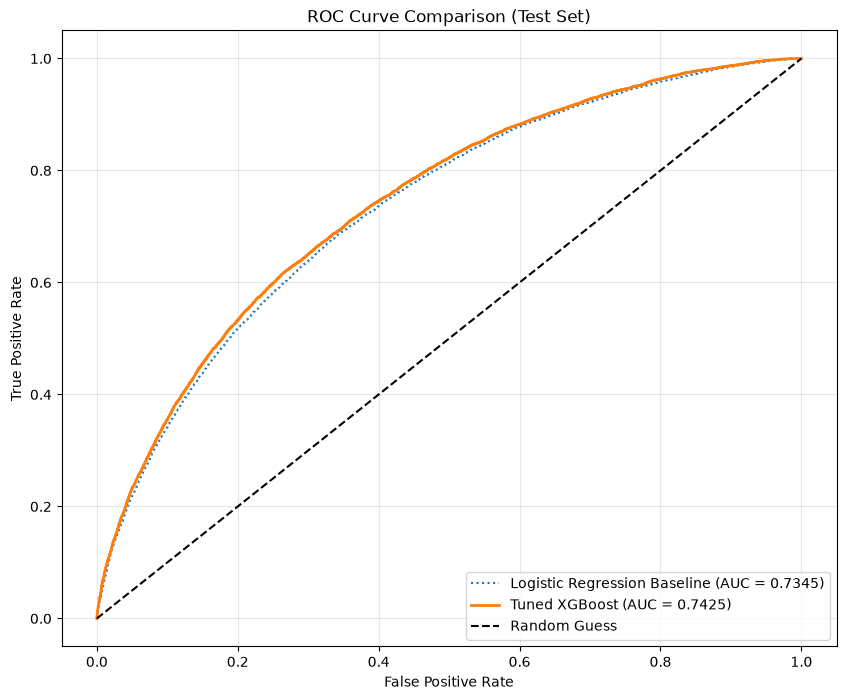

In [112]:
# Plot ROC AUC Curves for baseline and tuned XGBoost on Test Set
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_test_pred_proba_lr)
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_test_pred_proba_xgb)

plt.figure(figsize=(10, 8))
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression Baseline (AUC = {roc_auc_lr_test:.4f})', linestyle=':')
plt.plot(fpr_xgb, tpr_xgb, label=f'Tuned XGBoost (AUC = {roc_auc_xgb_test:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison (Test Set)')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [113]:
pred_df = pd.DataFrame({
    'lr': y_test_pred_proba_lr,
    'xgb': y_test_pred_proba_xgb,
})

print(pred_df.corr())

           lr       xgb
lr   1.000000  0.962231
xgb  0.962231  1.000000


In [114]:
# Save tuned XGBoost model, metadata, and test set for SHAP explainability later
model_metadata = {
    'model_name': 'xgboost_baseline',
    'model_type': 'XGBClassifier',
    'selection_metric': 'validation_roc_auc',
    'best_params': grid.best_params_,
    'best_cv_roc_auc': float(grid.best_score_),
    'train_roc_auc': float(roc_auc_xgb_train),
    'validation_roc_auc': float(roc_auc_xgb_val),
    'test_roc_auc': float(roc_auc_xgb_test),
    'feature_count': int(X_train.shape[1]),
    'training_rows': int(X_train.shape[0]),
    'validation_rows': int(X_val.shape[0]),
    'test_rows': int(X_test.shape[0]),
    'positive_class': 'Charged Off',
    'negative_class': 'Fully Paid',
    'llm_guardrail': 'The LLM never approves or rejects loans; it only summarizes evidence for a human underwriter.',
}

joblib.dump(best_xgb, "../models/xgboost_baseline.joblib")
with open("../models/metadata.json", "w") as f:
    json.dump(model_metadata, f, indent=2)
X_test.to_parquet("../data/processed/features/X_test_baseline.parquet")
print("Tuned XGBoost model, metadata, and test data successfully saved.")

Tuned XGBoost model, metadata, and test data successfully saved.


In [116]:
print(X_train.columns.tolist())

['loan_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'mths_since_last_delinq', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'policy_code', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_rev_tl_bal_gt_0', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'issue_year', 'issue_month', 'credit_history_months', 'term_months',